# Logistic regression

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Read dataset
df_new = pd.read_csv(r"C:\Users\charulatha\OneDrive\Desktop\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv")
df_new

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Gluten_Free_label,Food_Name_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0,6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31320,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,72.507408,...,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
31321,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,...,0,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
31322,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,...,0,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31323,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,...,0,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df_new.columns

Index(['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
       'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
       'Is_Vegan_label', 'Is_Gluten_Free_label', 'Food_Name_label',
       'Meal_Type_breakfast', 'Meal_Type_dinner', 'Meal_Type_lunch',
       'Meal_Type_snack', 'Preparation_Method_baked',
       'Preparation_Method_fried', 'Preparation_Method_grilled',
       'Preparation_Method_raw'],
      dtype='str')

In [55]:
# Features for model
cols = [
    'Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
    'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
    'Is_Vegan_label', 'Is_Gluten_Free_label',
    'Meal_Type_breakfast', 'Meal_Type_dinner', 'Meal_Type_lunch',
    'Meal_Type_snack', 'Preparation_Method_baked',
    'Preparation_Method_fried', 'Preparation_Method_grilled',
    'Preparation_Method_raw']

X = df_new[cols]
y = df_new["Food_Name_label"]


In [56]:
from sklearn.model_selection import train_test_split

# 20% test, 60% train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

print("Train X shape:", X_train.shape)
print("Train Y shape:", y_train.shape)
print("Test X shape:", X_test.shape)
print("Test Y shape:", y_test.shape)

Train X shape: (25060, 21)
Train Y shape: (25060,)
Test X shape: (6265, 21)
Test Y shape: (6265,)


In [57]:
# Standard scaler 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
# model creation
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs', 
)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [59]:
y_train_pred = model.predict(X_train)
y_train_pred


array([8, 0, 6, ..., 0, 6, 2], shape=(25060,))

In [60]:
y_test_pred = model.predict(X_test)
y_test_pred

array([5, 5, 6, ..., 5, 2, 5], shape=(6265,))

In [61]:
y_test.iloc[66]

np.int64(0)

In [62]:
y_test_pred[66]

np.int64(0)

### Score accuracy

In [63]:
# Score accuracy for prediction
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train accuracy after prediction :", train_acc)
print("Test accuracy after prediction:", test_acc)


Train accuracy after prediction : 0.9948124501197126
Test accuracy after prediction: 0.9948922585794094


### Confusion matrix for prediction value

In [64]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
cm

array([[ 291,    3,    0,    0,    0,    0,    0,    0,    0,    0],
       [   1,  236,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,  981,    3,    0,    0,    5,    0,    0,    0],
       [   0,    0,    1,  892,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,  593,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,  792,    0,    0,    0,    0],
       [   0,    0,   15,    2,    0,    0, 1166,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,  197,    0,    0],
       [   0,    0,    0,    0,    2,    0,    0,    0,  395,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0,  690]])

Text(95.72222222222221, 0.5, 'Actual')

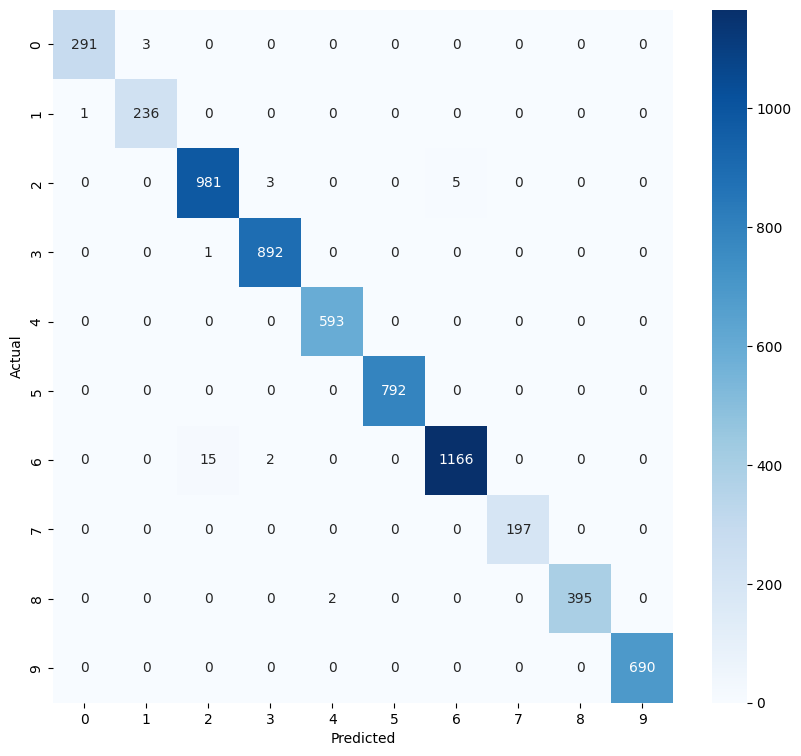

In [65]:

plt.figure(figsize = (10, 9))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [66]:
from sklearn.metrics import classification_report

# Classification report
y_pred = model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       294
           1       0.99      1.00      0.99       237
           2       0.98      0.99      0.99       989
           3       0.99      1.00      1.00       893
           4       1.00      1.00      1.00       593
           5       1.00      1.00      1.00       792
           6       1.00      0.99      0.99      1183
           7       1.00      1.00      1.00       197
           8       1.00      0.99      1.00       397
           9       1.00      1.00      1.00       690

    accuracy                           0.99      6265
   macro avg       1.00      1.00      1.00      6265
weighted avg       0.99      0.99      0.99      6265



# Principal Component Analysis (PCA) - Input Features

In [67]:
df_new

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Gluten_Free_label,Food_Name_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0,6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31320,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,72.507408,...,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
31321,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,...,0,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
31322,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,...,0,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31323,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,...,0,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [68]:
df_new.loc[0]

Calories                      290.463673
Protein                        14.340084
Fat                            14.152608
Carbs                          35.266644
Sugar                           4.828030
Fiber                           1.291432
Sodium                        647.553389
Cholesterol                    24.990309
Glycemic_Index                 81.575896
Water_Content                  45.669118
Serving_Size                  197.570043
Is_Vegan_label                  0.000000
Is_Gluten_Free_label            0.000000
Food_Name_label                 6.000000
Meal_Type_breakfast             0.000000
Meal_Type_dinner                1.000000
Meal_Type_lunch                 0.000000
Meal_Type_snack                 0.000000
Preparation_Method_baked        0.000000
Preparation_Method_fried        1.000000
Preparation_Method_grilled      0.000000
Preparation_Method_raw          0.000000
Name: 0, dtype: float64

In [69]:
df_pca = df_new.copy()
df_pca

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Gluten_Free_label,Food_Name_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0,6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31320,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,72.507408,...,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
31321,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,...,0,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
31322,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,...,0,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31323,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,...,0,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [70]:
# Feature for PCA
X_pca = df_pca.drop(columns=['Food_Name_label'])
y = df_new['Food_Name_label']
X_pca.shape

(31325, 21)

In [71]:
np.unique(y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [72]:
from sklearn.preprocessing import StandardScaler

#Standard scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)
X_scaled

array([[ 0.23626248,  0.82269474,  0.30938543, ...,  1.75737251,
        -0.57822267, -0.57851757],
       [-0.64765663, -0.82183419, -0.07839377, ..., -0.56903132,
        -0.57822267,  1.72855598],
       [ 0.69313562,  0.82055065,  1.16660883, ..., -0.56903132,
        -0.57822267,  1.72855598],
       ...,
       [ 0.3445245 ,  0.5168308 , -0.09505546, ..., -0.56903132,
         1.72943756, -0.57851757],
       [ 0.93673259, -0.0060202 , -0.58106992, ..., -0.56903132,
         1.72943756, -0.57851757],
       [-0.74615803, -0.62278491,  0.19704214, ..., -0.56903132,
         1.72943756, -0.57851757]], shape=(31325, 21))

In [73]:
from sklearn.decomposition import PCA

# PCA
pca = PCA(0.97)

X_PCA = pca.fit_transform(X_scaled)
X_PCA.shape

(31325, 14)

#### The application of PCA reduced the original 21-dimensional feature space to 14 principal components while retaining approximately 95% of the total variance. This dimensionality reduction helps remove redundancy and multicollinearity among input features.

In [74]:
pca.n_components_

np.int64(14)

In [75]:
X_PCA[0]

array([ 1.95030787,  0.5325502 ,  1.02195234, -0.10025152, -0.94546976,
        0.23707672, -0.14769446, -1.1972528 ,  2.38109889,  0.12987271,
        0.62675794,  0.3265968 , -0.54987844,  0.42547575])

Cumulative explained variance: 0.9762609307432177


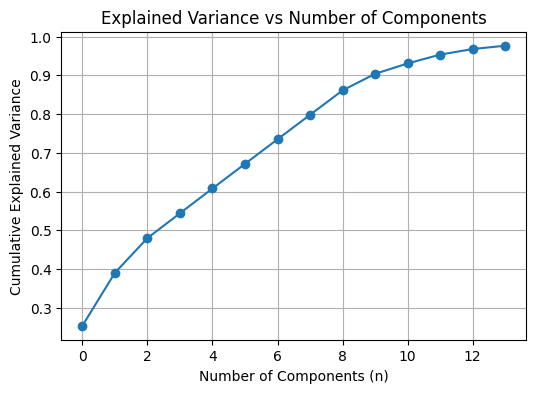

In [76]:
import numpy as np


print("Cumulative explained variance:",
      np.sum(pca.explained_variance_ratio_))

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components (n)")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.grid()
plt.show()

In [77]:
from sklearn.model_selection import train_test_split

# 20% test, 60% train
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_PCA, y, test_size=0.2, random_state=30, stratify=y)

In [78]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs', 
    )
model.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [79]:
y_train_pred1 = model.predict(X_train_pca)
y_train_pred1

array([0, 6, 8, ..., 2, 6, 6], shape=(25060,))

In [80]:
y_test_pred2 = model.predict(X_test_pca)
y_test_pred2

array([2, 5, 6, ..., 6, 3, 3], shape=(6265,))

In [81]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, y_train_pred1)
test_acc = accuracy_score(y_test, y_test_pred2)

print("Train accuracy after prediction :", train_acc)
print("Test accuracy after prediction:", test_acc)

Train accuracy after prediction : 0.9914604948124501
Test accuracy after prediction: 0.9902633679169992


### Confusion matrix for prediction value --- After PCA

In [82]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test, y_test_pred2)
cm1

array([[ 289,    5,    0,    0,    0,    0,    0,    0,    0,    0],
       [   2,  235,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,  966,    0,    0,    4,   19,    0,    0,    0],
       [   0,    0,    2,  891,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,  589,    0,    0,    0,    4,    0],
       [   0,    0,    2,    0,    0,  790,    0,    0,    0,    0],
       [   0,    0,   18,    0,    0,    0, 1165,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,  197,    0,    0],
       [   0,    0,    0,    0,    1,    0,    0,    0,  396,    0],
       [   0,    0,    0,    0,    2,    0,    0,    0,    2,  686]])

Text(95.72222222222221, 0.5, 'Actual')

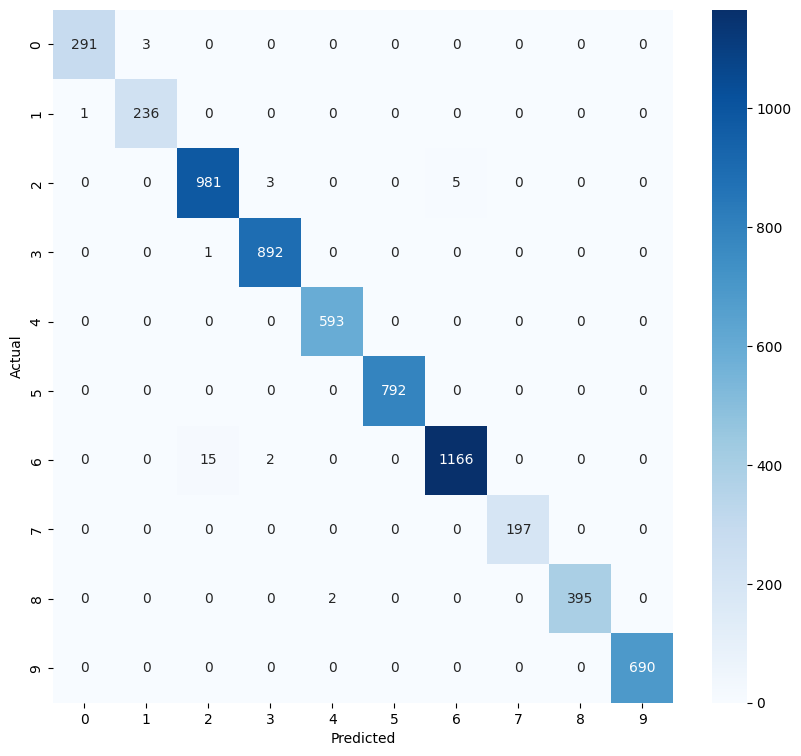

In [85]:
plt.figure(figsize = (10, 9))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [84]:
from sklearn.metrics import classification_report

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred2))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       294
           1       0.98      0.99      0.99       237
           2       0.98      0.98      0.98       989
           3       1.00      1.00      1.00       893
           4       0.99      0.99      0.99       593
           5       0.99      1.00      1.00       792
           6       0.98      0.98      0.98      1183
           7       1.00      1.00      1.00       197
           8       0.99      1.00      0.99       397
           9       1.00      0.99      1.00       690

    accuracy                           0.99      6265
   macro avg       0.99      0.99      0.99      6265
weighted avg       0.99      0.99      0.99      6265

